# LVM DR20 Model File Tutorial (Detailed)

This notebook explains how to read and interpret **LVM DAP model files** in DR20.

## Scientific context
The model file encodes the decomposition of each observed spectrum into:
- stellar continuum
- emission-line gas (non-parametric and parametric)
- residuals and combined models

Each fiber corresponds to a spatial element in the LVM field of view.

## Goal
Understand how to:
1. Read the FITS structure
2. Extract spectra and components
3. Interpret each model contribution
4. Diagnose fitting quality


### Explanation

This cell performs part of the workflow related to reading, processing, or visualizing the DAP model data.

In [1]:
__author__ = 'Sebastian F. Sanchez and LVM team'
__version__ = '20260420'
__datasets__ = ['SDSS-V LVM DAP (DRPVER=1.2.0, DAPVER = 1.2.0.251218, MJD=60191, EXPNUM=4297)']  
__keywords__ = ['Helix nebula','LVM','DR20','model spectra','tutorial']


# LVM DAP output-model generation tutorial

This notebook is a tutorial version of the standalone `gen_output_model.py` workflow, included in the LVMDAP distribution, following the configuration strategy used in the notebook `lvm-dap-gen-out-mod.ipynb` (also nicluded in the LVMDAP distribution), that, instead of reading a separate YAML file, it reads the configuration parameters directly from the `INFO` extension of the DAP FITS file.

The notebook reconstructs the same model products:
- original observed spectra,
- stellar model,
- non-parametric gas model,
- parametric gas model,
- joint model and residual products,

and writes them to a multi-plane FITS file.


## Dependencies

This notebook requires:

- `numpy`
- `scipy`
- `astropy`
- `matplotlib`


Recommended installation in a conda environment:

```bash
pip install numpy scipy astropy matplotlib import
```



## 1. Imports and thread control

### Explanation

This cell generates a plot of the spectra or model components. Each curve corresponds to a different physical component (observed, stellar, gas, etc.).

In [31]:
#
# We use one single thread to avoid problems with the use of multiple threads in some of the used libraries, which can cause problems when running in parallel with multiprocessing.
#
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from pathlib import Path
import numpy as np

from astropy.table import Table,join
from astropy.io import fits
from sdss_access import Access
from pathlib import Path
import os
import matplotlib.pyplot as plt
import math
from pprint import pprint
from astropy.convolution import convolve
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d,median_filter
from numpy.polynomial.legendre import Legendre
from matplotlib.ticker import MultipleLocator

from sdss_access import Access
access = Access(release='dr20', verbose=True)


## 2. Input files

Locate the input files using `sdss_access` or `Tree`

This notebook first tries to locate the example DR20 Helix dataset using `sdss_access`, then falls back to `Tree`, and only if both fail does it look for local files in the working directory. This makes the tutorial more portable across environments while keeping the dataset definition explicit.


### Explanation

This cell performs part of the workflow related to reading, processing, or visualizing the DAP model data.

In [13]:
drpver = "1.2.0"
dapver = '1.2.0.251218' 
DIR_CACHE = 'cache/'
if not os.path.isdir(DIR_CACHE):
    os.mkdir(DIR_CACHE)
DRVER = 'DR20'
DIR_DAP = 'dap_v1.2.0/'
DIR_FIG = 'figs/'
tilegrp = '0011XX'
tileid = '11111'
mjd = '60191'
expnum = '00004297'
mjd = 60191
rsp = 'rsp108'
sn = 'sn20'
i_expnum = int(expnum)
dap_model_file = f'dap-{rsp}-{sn}-{expnum}.model.fits'

## Load DAP dataproduct, DAP-file

### Explanation

This cell performs part of the workflow related to reading, processing, or visualizing the DAP model data.

In [14]:
# try:
    ##################################################
    # (1.1) Get the data using the sdss_access pachage
    ##################################################
path_to_data_file = access.full('lvm_model',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
if not os.path.isfile(path_to_data_file):
    access.remote()
    kind = 'dap'    
    access.add('lvm_model', drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    access.set_stream()
    access.commit()
    # PATH to lvmDAP file
    path_to_data_file = access.full('lvm_model',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    # print(path_to_data_file)
    # Open data file and print a summary of the Header Data Units
dap_model_file = path_to_data_file
# except:
#     ################################################################
#     # (1.2) Get the data from a local directory
#     ################################################################
#     dap_file=f'dap-{rsp}-{sn}-{expnum}.dap.fits.gz'
#     dap_file=f'{DIR_DAP}/{dap_file}'



[ERROR]: Traceback (most recent call last):
  File "/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_344290/1869706172.py", line 5, in <module>
    path_to_data_file = access.full('lvm_model',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sanchez/.local/lib/python3.11/site-packages/sdss_access/path/path.py", line 706, in full
    assert filetype in self.templates, ('No entry {0} found. Filetype must '
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: No entry lvm_model found. Filetype must be one of the designated templates in the currently loaded tree



### Explanation

This cell performs part of the workflow related to reading, processing, or visualizing the DAP model data.

In [20]:
#
# Local Patch
#
dap_model_file = f'{DIR_DAP}/dap-{rsp}-{sn}-{expnum}.model.fits'

### Explanation

This cell opens the DAP model FITS file and inspects its HDU structure. The model file contains multiple spectral components stored as a 3D cube.

In [27]:
hdu_outmod = fits.open(dap_model_file)
print(hdu_outmod.info())
cube = hdu_outmod[0].data
wave = hdu_outmod[0].header['CRVAL1'] + np.arange(hdu_outmod[0].header['NAXIS1'])*hdu_outmod[0].header['CDELT1']
dap_fwhm = 1.0
f_scale=1e16
hdu_outmod[0].header


Filename: dap_v1.2.0//dap-rsp108-sn20-00004297.model.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (12401, 1754, 9)   float32   
None


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                12401                                                  
NAXIS2  =                 1754                                                  
NAXIS3  =                    9                                                  
EXTEND  =                    T                                                  
PIPELINE= 'pyPipe3D v1.1.5'                                                     
UNIXTIME=           1769692726 / 2026-01-29 07:18:46.233775                     
CRPIX1  =                    1                                                  
CRVAL1  =               3600.0                                                  
CDELT1  =                  0.5                                                  
NAME0   = 'org_spec'        

# 3 Showing the results

Plot the generated model together with the original spectra for a particular fiber (fib)

### Explanation

This cell generates a plot of the spectra or model components. Each curve corresponds to a different physical component (observed, stellar, gas, etc.).

(6500.0, 6740.0)

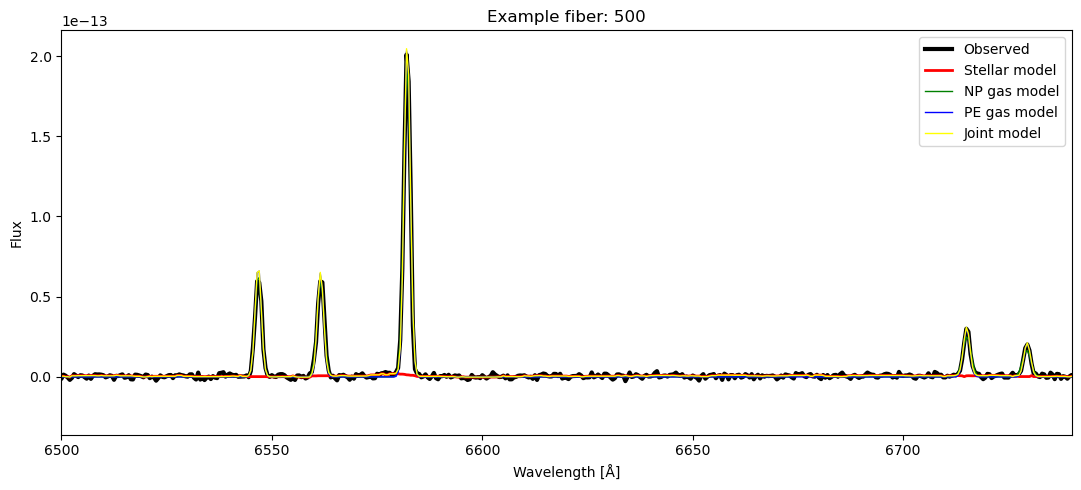

In [28]:
fib = 500
%matplotlib inline
plt.figure(figsize=(11, 5))
plt.plot(wave, cube[0, fib, :], label="Observed", lw=3, color="black")
plt.plot(wave, cube[1, fib, :], label="Stellar model", lw=2, color="red")
plt.plot(wave, cube[6, fib, :], label="NP gas model", lw=1, color="green")
plt.plot(wave, cube[7, fib, :], label="PE gas model", lw=1, color="blue")
plt.plot(wave, cube[2, fib, :], label="Joint model", lw=1, color="yellow")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title(f"Example fiber: {fib}")
plt.legend()
plt.tight_layout()
plt.xlim(6500, 6740)
#plt.show()

### Explanation

This cell performs part of the workflow related to reading, processing, or visualizing the DAP model data.

In [46]:
av_spec = np.nanmean(cube, axis=1)
print(av_spec.shape) 

(9, 12401)


### Explanation

This cell generates a plot of the spectra or model components. Each curve corresponds to a different physical component (observed, stellar, gas, etc.).

(-5e-15, 1.3e-13)

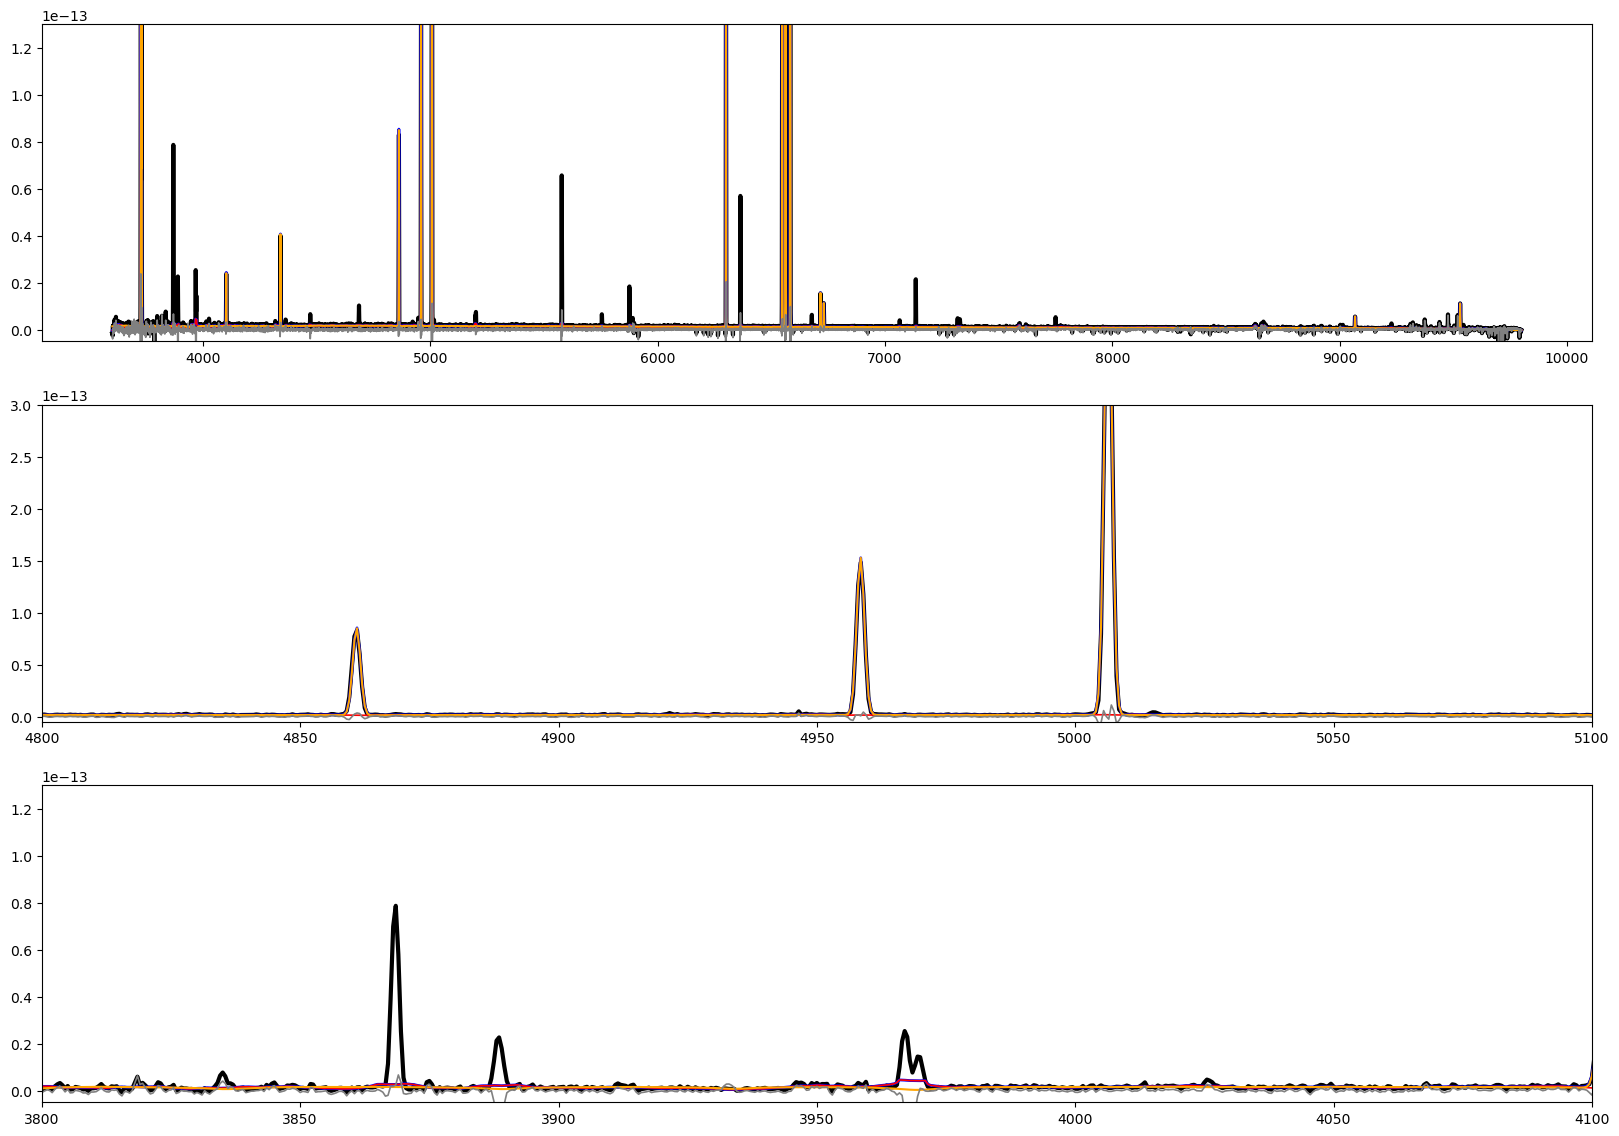

In [47]:
##################################################################################
# We plot the average spectra and the average model spectra
##################################################################################

%matplotlib inline
fig, ax = plt.subplots(3, 1, figsize=(20, 14))
#plt.imshow(model_spectra[7, :, :], aspect='auto', origin='lower')

for ax_now in ax.flatten():
    ax_now.plot(wave, av_spec[0,:],color='black',linewidth=3)
    ax_now.plot(wave, av_spec[2,:],color='blue',linewidth=2,alpha=1.0)
#    ax_now.plot(wave, np.nanmean(model_spectra[6, :, :],axis=0),color='blue',linewidth=1.5)
#    ax_now.plot(wave, np.nanmean(model_spectra[7, :, :],axis=0),color='darkblue',linewidth=1.5)
    ax_now.plot(wave, av_spec[1,:],color='red',linewidth=1.2)
    ax_now.plot(wave, av_spec[8,:],color='orange',linewidth=1.5,alpha=1.0)
    ax_now.plot(wave, av_spec[4,:],color='grey',linewidth=1.2)
#ax[0].set_xlim(3800, 4100)
ax[0].set_ylim(-50/f_scale, 1300/f_scale)

ax[1].set_xlim(4800, 5100)
ax[1].set_ylim(-50/f_scale, 3000/f_scale)

ax[2].set_xlim(3800, 4100)
ax[2].set_ylim(-50/f_scale, 1300/f_scale)
#plt.show()

### Explanation

This extracts the wavelength array and data cube. The cube typically has dimensions (component, fiber, wavelength).

In [90]:
def gamma_scale_test(flux,gamma):
    return flux

def gamma_scale(flux,gamma):
    return (flux/np.abs(flux))*(np.abs(flux))**gamma

def gamma_scale_abs(flux,gamma):
    return (np.abs(flux))**gamma

def my_medfilt (x, k):
    """Apply a length-k median filter to a 1D array x.
    Boundaries are extended by repeating endpoints.
    """
    import numpy as np

    assert k % 2 == 1, "Median filter length must be odd."
    assert x.ndim == 1, "Input must be one-dimensional."
    
    k2 = (k - 1) // 2
    y = np.zeros ((len (x), k), dtype=x.dtype)
    y[:,k2] = x
    for i in range (k2):
        j = k2 - i
        y[j:,i] = x[:-j]
        y[:j,i] = x[0]
        y[:-j,-(i+1)] = x[j:]
        y[-j:,-(i+1)] = x[-1]
    return np.median (y, axis=1)


def my_meanfilt (x, k):
    """Apply a length-k mean filter to a 1D array x.
    Boundaries are extended by repeating endpoints.
    """
    
    import numpy as np

    assert k % 2 == 1, "Median filter length must be odd."
    assert x.ndim == 1, "Input must be one-dimensional."
    
    k2 = (k - 1) // 2
    y = np.zeros ((len (x), k), dtype=x.dtype)
    y[:,k2] = x
    for i in range (k2):
        j = k2 - i
        y[j:,i] = x[:-j]
        y[:j,i] = x[0]
        y[:-j,-(i+1)] = x[j:]
        y[-j:,-(i+1)] = x[-1]
    return np.mean (y, axis=1)



def plot_spec_now_3pg(
    data_2d,
    wave=None,
    *,
    crval=None,
    cdelt=None,
    crpix=None,
    name='none',
    cmap=None,
    x_min=(3600, 3600, 3600),
    x_max=(9600, 9600, 9600),
    y_min=-0.2,
    y_max=2,
    text='',
    no_st=False,
    no_model=False,
    log=False,
    id_lines=None,
    output='junk.pdf',
    c_map='carlos',
    do_legend=True,
    insets=None,
    y0_d=0.5,
    y1_d=2.5,
    plot_el=False,
    tab_el=None,
    colors_in=('black', 'red', 'deepskyblue', 'blue', 'gold', 'forestgreen'),
    plot_res=False,
    show_scale=True,
    n_ord=11,
    gamma=0.3,
    props=None,
    alpha=0.5,
    SN_sc_lim=3,
    ):

    if props is None:
        props = dict(facecolor='lightgrey', alpha=0.5, edgecolor='darkgrey')

    data = np.asarray(data_2d, dtype=float)
    if data.ndim != 2:
        raise ValueError("data_2d must be a 2D array with shape (ny, nx).")

    ny, nx = data.shape

    if wave is None:
        if crval is None or cdelt is None or crpix is None:
            raise ValueError(
                "Provide either 'wave' or all of 'crval', 'cdelt', and 'crpix'."
            )
        wave = crval + cdelt * (np.arange(nx) - (crpix - 1))
    else:
        wave = np.asarray(wave, dtype=float)
        if wave.ndim != 1 or wave.shape[0] != nx:
            raise ValueError("wave must be a 1D array with length equal to data_2d.shape[1].")

    if cmap is None:
        cmap = 'Spectral'

    i0 = int(nx * 0.15)
    i1 = int(nx * 0.25)

    med_sc = np.abs(np.nanmedian(data[0, i0:i1]))
    std_sc = np.nanstd(data[0, i0:i1])
    SN_sc = med_sc / std_sc if std_sc != 0 else np.inf
    print(f'# S/N: {SN_sc} {med_sc} {std_sc}')

    if med_sc == 0 or not np.isfinite(med_sc):
        raise ValueError("Normalization median is zero or invalid.")

    data = data / med_sc

    smooth = np.zeros(nx, dtype=float)



    ssp_model = data[1]

    fig = plt.figure(figsize=(19, 19))
    gs = fig.add_gridspec(
        nrows=10,
        ncols=12,
        left=0.175,
        right=0.97,
        hspace=0.35,
        wspace=0.05,
        bottom=0.15,
        top=0.9,
    )

    ax2 = fig.add_subplot(gs[8:10, :])
    ax0 = fig.add_subplot(gs[0:2, :])
    ax0m = fig.add_subplot(gs[2:4, :])
    ax0u = fig.add_subplot(gs[4:6, :])

    ax2.set_xticks([])
    ax2.set_yticks([])
    plt.setp(ax2.spines.values(), color=None)

    ax0.set_xlim(x_min[0], x_max[0])
    ax0m.set_xlim(x_min[1], x_max[1])
    ax0u.set_xlim(x_min[2], x_max[2])

    sign = 1 if y_min >= 0 else -1
    ax0.set_ylim(sign * np.abs(y_min**gamma), y_max**gamma)
    ax0u.set_ylim(sign * np.abs(y_min**gamma), y_max**gamma)
    ax0m.set_ylim(sign * np.abs(y_min**gamma), y_max**gamma)

    colors = list(colors_in)
    res = data[4] 
    gas_model = data[7]

    #NAME0   = 'org_spec'                                                            
    #NAME1   = 'model_spec'                                                          
    #NAME2   = 'mod_joint_spec'                                                      
    #NAME3   = 'gas_spec'                                                            
    #NAME4   = 'res_joint_spec'                                                      
    #NAME5   = 'no_gas_spec'                                                         
    #NAME6   = 'gas_model_NP'                                                        
    #NAME7   = 'gas_model_PEK'                                                       
    #NAME8   = 'mod_joint_spec_PEK'  

    if not no_st:
        ax0.plot(
            wave,
            gamma_scale(data[0, :], gamma),
            color=colors[0],
            alpha=1.0,
            linewidth=3.0,
            label=r'Obs. Spectrum (O$_\lambda$)',
        )
        ax0u.plot(
            wave,
            gamma_scale(data[0, :], gamma),
            color=colors[0],
            alpha=1.0,
            linewidth=3.0,
            label=r'Obs. Spectrum (O$_\lambda$)',
        )
        ax0m.plot(
            wave,
            gamma_scale(data[0, :], gamma),
            color=colors[0],
            alpha=1.0,
            linewidth=3.0,
            label=r'Obs. Spectrum (O$_\lambda$)',
        )

        if not no_model:
            ax0.plot(
                wave,
                gamma_scale(ssp_model, gamma),
                color=colors[1],
                alpha=alpha,
                linewidth=1.5,
                label=r'St. Model (M$_\lambda$)',
                linestyle='solid',
            )
            ax0u.plot(
                wave,
                gamma_scale(ssp_model, gamma),
                color=colors[1],
                alpha=alpha,
                linewidth=1.5,
                label=r'St. Model (M$_\lambda$)',
                linestyle='solid',
            )
            ax0m.plot(
                wave,
                gamma_scale(ssp_model, gamma),
                color=colors[1],
                alpha=alpha,
                linewidth=1.5,
                label=r'St. Model (M$_\lambda$)',
                linestyle='solid',
            )

    ax0.plot(
        wave,
        gamma_scale(data[0, :] + smooth, gamma) - gamma_scale(data[1, :], gamma),
        color=colors[2],
        alpha=alpha,
        label=r'St. Residual (O$_\lambda$-M$_\lambda$)',
        linewidth=3,
    )
    ax0u.plot(
        wave,
        gamma_scale(data[0, :] + smooth, gamma) - gamma_scale(data[1, :], gamma),
        color=colors[2],
        alpha=alpha,
        label=r'St. Residual (O$_\lambda$-M$_\lambda$)',
        linewidth=3,
    )
    ax0m.plot(
        wave,
        gamma_scale(data[0, :] + smooth, gamma) - gamma_scale(data[1, :], gamma),
        color=colors[2],
        alpha=alpha,
        label=r'St. Residual (O$_\lambda$-M$_\lambda$)',
        linewidth=3,
    )

    if not no_model:
        ax0.plot(
            wave,
            gamma_scale(data[2, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[3],
            alpha=alpha,
            linewidth=1.5,
            label=r'Em. Lines model (E$_\lambda$)',
            linestyle='solid',
        )
        ax0u.plot(
            wave,
            gamma_scale(data[2, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[3],
            alpha=alpha,
            linewidth=1.5,
            label=r'Em. Lines model (E$_\lambda$)',
            linestyle='solid',
        )
        ax0m.plot(
            wave,
            gamma_scale(data[2, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[3],
            alpha=alpha,
            linewidth=1.5,
            label=r'Em. Lines model (E$_\lambda$)',
            linestyle='solid',
        )

    if plot_res:
        ax0.plot(
            wave,
            gamma_scale(data[1, :] + data[4, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[4],
            alpha=alpha,
            linewidth=1.5,
            label=r'Final residual (R$_\lambda$)',
            linestyle='solid',
        )
        ax0m.plot(
            wave,
            gamma_scale(data[1, :] + data[4, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[4],
            alpha=alpha,
            linewidth=1.5,
            label=r'Final residual (R$_\lambda$)',
            linestyle='solid',
        )
        ax0u.plot(
            wave,
            gamma_scale(data[1, :] + data[4, :], gamma) - gamma_scale(data[1, :], gamma),
            color=colors[4],
            alpha=alpha,
            linewidth=1.5,
            label=r'Final residual (R$_\lambda$)',
            linestyle='solid',
        )

    _std_res = np.std(res[2000:2500]) if nx > 2500 else np.std(res)
    _flux = np.median(data[1, 2000:2500]) if nx > 2500 else np.median(data[1, :])

    ax0.xaxis.set_minor_locator(MultipleLocator(100))
    handles, labels = ax0.get_legend_handles_labels()
    if do_legend:
        ax0.legend(
            handles,
            labels,
            loc=(-0.005, 1.01),
            frameon=True,
            handlelength=1.5,
            ncol=5,
            columnspacing=0.15,
            prop={'size': 22},
        )

    if id_lines is not None:
        mask_lines = (id_lines['wl'].value >= x_min[0]) & (id_lines['wl'].value < x_max[2])
        tab_elines = id_lines[mask_lines]
        even = 0
        for line in tab_elines:
            ax0.text(
                line['wl'],
                y_max - 0.16 * (even + 1) * (y_max - y_min),
                f"{line['wl']}",
                color=colors[even],
                fontsize=16,
                horizontalalignment='center',
                rotation='vertical',
            )
            even += 1
            if even > 2:
                even = 0

    if insets is not None:
        for i_inst, inst in enumerate(insets):
            axins = ax0.inset_axes(
                [inst[0], inst[1], inst[2], inst[3]],
                xlim=(inst[4], inst[5]),
                ylim=(inst[6], inst[7]),
                yticklabels=[],
            )
            if i_inst in (0, 9):
                axins.set_ylabel(r'Flux$_\lambda$', fontsize=23)

            if not no_st:
                axins.plot(
                    wave,
                    data[0, :],
                    color=colors[0],
                    alpha=1.0,
                    linewidth=3,
                    label=r'Observed (O$_\lambda$)',
                )
            if not no_model:
                axins.plot(
                    wave,
                    ssp_model,
                    color=colors[1],
                    alpha=1.0,
                    linewidth=1.5,
                    label=r'Model (M$_\lambda$)',
                    linestyle='solid',
                )
            axins.plot(
                wave,
                res,
                color=colors[2],
                alpha=1.0,
                linewidth=3,
                label=r'Residual (O$_\lambda$-M$_\lambda$)',
            )
            if not no_model:
                axins.plot(
                    wave,
                    gas_model,
                    color=colors[3],
                    alpha=1.0,
                    linewidth=1.5,
                    label=r'E. lines model',
                    linestyle='solid',
                )
            if plot_res:
                axins.plot(
                    wave,
                    data[4, :],
                    color=colors[4],
                    alpha=1.0,
                    linewidth=1.5,
                    label=r'Em. lines model (E$_\lambda$)',
                    linestyle='solid',
                )

            if plot_el:
                tab_el_now = tab_el[(tab_el['wl'] > inst[4]) & (tab_el['wl'] < inst[5])]
                for vals in tab_el_now:
                    axins.plot(
                        [vals['wl'], vals['wl']],
                        [
                            inst[7] - 0.05 * abs(inst[7] - inst[6]),
                            inst[7] - 0.15 * abs(inst[7] - inst[6]),
                        ],
                        color='darkorange',
                        linewidth=2,
                    )
                axins.text(
                    inst[4] + 0.1 * np.abs(inst[5] - inst[4]),
                    inst[7] - 0.15 * abs(inst[7] - inst[6]),
                    fr'\bf {inst[8]}',
                    bbox=props,
                )

    ax0.text(
        x_min[0] + 0.05 * (x_max[0] - x_min[0]),
        y_min + 0.85 * (y_max - y_min),
        text,
        fontsize=21,
    )
    ax0m.text(
        x_min[1] + 0.05 * (x_max[1] - x_min[1]),
        y_min + 0.85 * (y_max - y_min),
        text,
        fontsize=21,
    )
    ax0u.text(
        x_min[2] + 0.05 * (x_max[2] - x_min[2]),
        y_min + 0.85 * (y_max - y_min),
        text,
        fontsize=21,
    )

    ax2.set_xlabel(r'rest-frame wavelength [\AA]', fontsize=23)

    if plot_el and tab_el is not None:
        for vals in tab_el:
            ax0.plot(
                [vals['wl'], vals['wl']],
                [
                    y_max**gamma - 0.02 * abs(y_max**gamma - y_min**gamma),
                    y_max**gamma - 0.10 * abs(y_max**gamma - y_min**gamma),
                ],
                color='darkorange',
            )
            ax0u.plot(
                [vals['wl'], vals['wl']],
                [
                    y_max**gamma - 0.02 * abs(y_max**gamma - y_min**gamma),
                    y_max**gamma - 0.10 * abs(y_max**gamma - y_min**gamma),
                ],
                color='darkorange',
            )
            ax0m.plot(
                [vals['wl'], vals['wl']],
                [
                    y_max**gamma - 0.02 * abs(y_max**gamma - y_min**gamma),
                    y_max**gamma - 0.10 * abs(y_max**gamma - y_min**gamma),
                ],
                color='darkorange',
            )

    if log:
        ax0.set_yscale('log')

    for axis in (ax0, ax0u, ax0m):
        axis.axvspan(5600, 5850, alpha=0.7, color='grey', zorder=10)
        axis.axvspan(7400, 7800, alpha=0.7, color='grey', zorder=10)
        axis.set_ylabel(r'Flux$^{0.5}_\lambda$', fontsize=23)

    plt.tight_layout()
    plt.show()
#    fig.savefig(output, transparent=False, facecolor='white', edgecolor='white')
#    plt.close(fig)

### Explanation

This cell generates a plot of the spectra or model components. Each curve corresponds to a different physical component (observed, stellar, gas, etc.).

[WARNING]: /tmp/ipykernel_344290/996627133.py:483: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



# S/N: 0.07366116988020996 1.655852797186611e-15 2.2479317120260367e-14


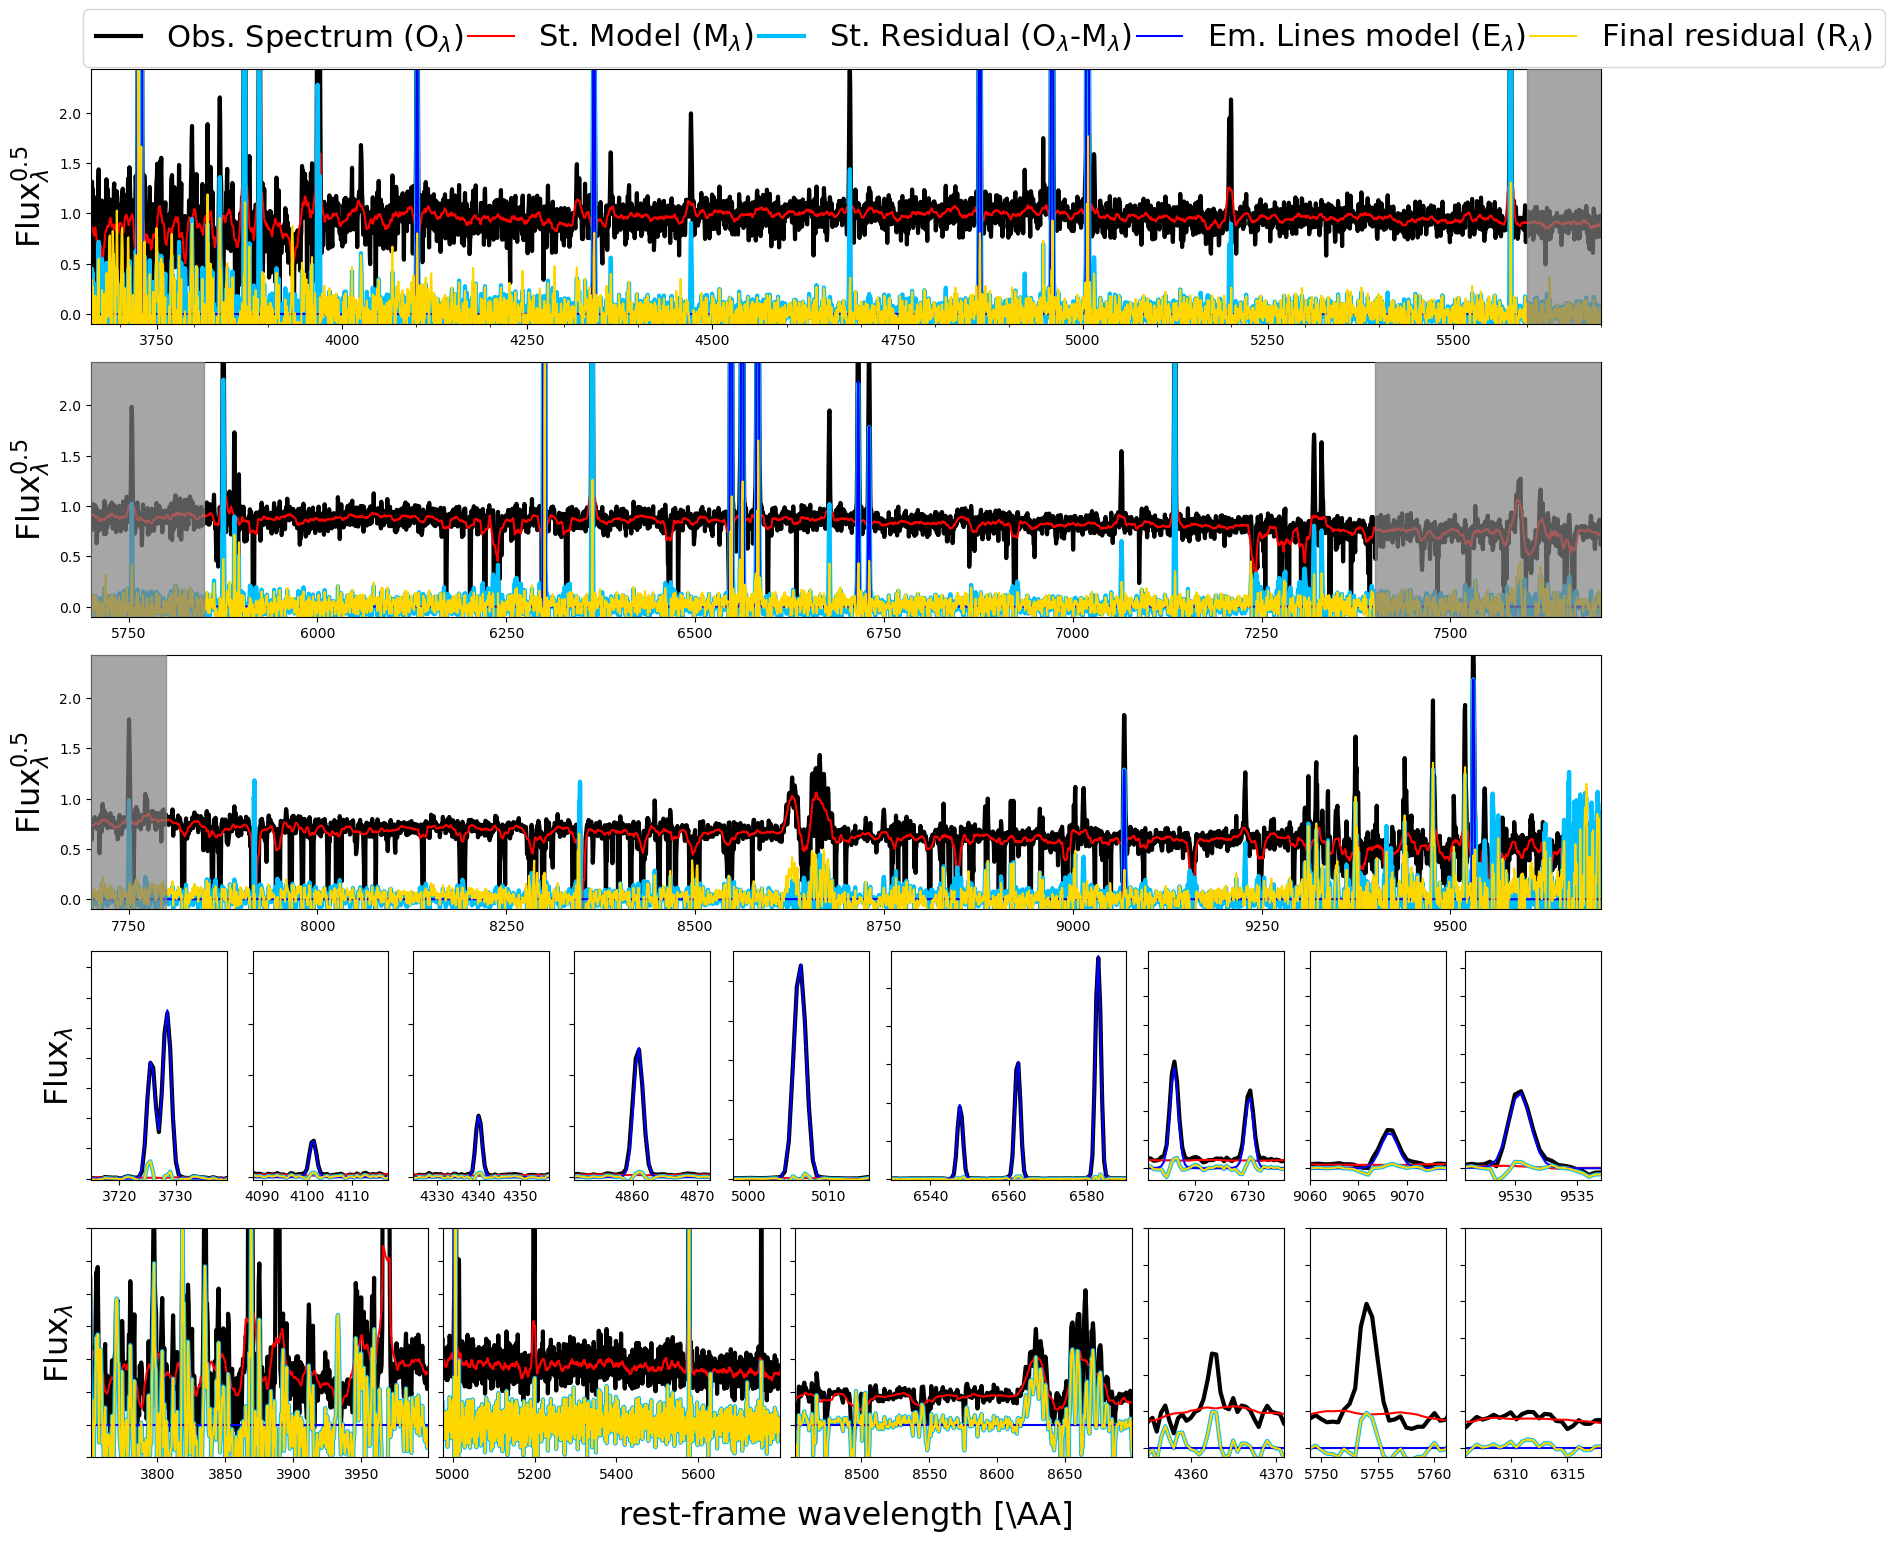

In [91]:
y_off = -2.27-1.09
y_off2 = -2.27-2.18
ranges = (3661,5700,7700,9700)
#ranges = (3600,3900,5700,7700,9700)
plot_spec_now_3pg(av_spec,wave,\
          name='Helix Nebulae',text='',c_map='CMRmap',output='figs/m_Helix_DR19.png',\
              insets=((0.00, y_off, 0.09, 0.9,3715,3739,-1,189,'[OII]'),\
                          (0.107, y_off, 0.09, 0.9,4088,4118,-1.0,89,r'H$\delta$'),\
                          (0.213, y_off, 0.09, 0.9,4324,4357,-1.0,89,r'H$\gamma$'),\
                          (0.320, y_off, 0.09, 0.9,4851,4872,-1.0,89,r'H$\beta$'),\
                          (0.425, y_off, 0.09, 0.9,4998,5015,-1.0,289,'[OIII]'),\
                          (0.530, y_off, 0.155, 0.9,6530,6590,-1,299,r'H$\alpha$+[NII]'),\
                          (0.700, y_off, 0.09, 0.9,6711,6737,-1.0,19,'[SII]'),\
                          (0.807, y_off, 0.09, 0.9,9060,9074,-1.0,19,'[SIII]'),\
                          (0.910, y_off, 0.09, 0.9,9526,9537,-1.0,19,'[SIII]'),\
                      (0.00, y_off2, 0.223, 0.9,3751,3999,-0.5,3,'3751-3999'),\
                      (0.233, y_off2, 0.223, 0.9,4976,5799,-0.5,3,'4976-5799'),\
                      (0.466, y_off2, 0.223, 0.9,8451,8699,-0.5,3,'8451-8699'),\
                      (0.700, y_off2, 0.09, 0.9,4363-8,4363+8,-0.25,6,'[OIII]'),\
                      (0.807, y_off2, 0.09, 0.9,5755-6,5755+6,-0.25,6,'[NII]'),\
                      (0.910, y_off2, 0.09, 0.9,6312-6,6312+6,-0.25,6,'[SIII]')
                     ),
                          y_min=-0.01,y_max=5.9,y0_d=0.3,y1_d=2.9,\
              x_min=(ranges[0],ranges[1],ranges[2]),x_max=(ranges[1],ranges[2],ranges[3]),plot_el=False,\
                plot_res=True,show_scale=False,n_ord=2,gamma=0.5,alpha=1.0, tab_el = None, SN_sc_lim=0.01)

### Explanation

This cell performs part of the workflow related to reading, processing, or visualizing the DAP model data.